# Fraud Detection Pipeline (`orders.is_fraud`) using CRISP-DM

## CRISP-DM Roadmap
1. **Business Understanding** *(this notebook section now)*
2. **Data Understanding** *(this notebook section now)*
3. **Data Preparation** *(next: feature engineering + train/validation split strategy)*
4. **Modeling** *(next: baseline + tuned models)*
5. **Evaluation** *(next: thresholding + business-cost analysis)*
6. **Deployment** *(next: batch/real-time scoring + monitoring)*

This notebook currently implements the first two phases in depth and prepares outputs needed for phases 3-6.

## Business Understanding

### Fraud-detection problem definition
We need to predict whether an order in the `orders` table is fraudulent (`is_fraud = 1`) before fulfillment decisions are finalized. This is a **binary classification** problem with class imbalance.

### Business objective
Reduce fraud losses while minimizing friction for legitimate customers.

### Decision context
Model outputs will be used to support operational actions such as:
- auto-approve low-risk orders,
- route medium-risk orders to manual review,
- auto-hold/cancel very high-risk orders.

### Success criteria
**Business KPIs**
- Lower net fraud loss rate (chargebacks + write-offs).
- Keep false-positive rate low enough to avoid unnecessary customer friction.
- Maintain acceptable manual-review volume.

**ML metrics**
- Prioritize **Recall** and **PR-AUC** for fraud class.
- Track precision at an operating threshold (e.g., top-k risk queue).
- Track ROC-AUC as a secondary separability metric.

### Constraints and assumptions
- Data source is `shop.db`; target leakage must be avoided.
- Features available at scoring time should be preferred.
- Since fraud prevalence is low, threshold selection must be business-cost aware.

## Data Understanding

In [1]:
# 2) Data Understanding - setup and data loading
import sqlite3
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

DB_PATH = "shop.db"

conn = sqlite3.connect(DB_PATH)

# Load core tables needed for understanding fraud dynamics
orders_df = pd.read_sql_query("SELECT * FROM orders", conn)
customers_df = pd.read_sql_query("SELECT * FROM customers", conn)
shipments_df = pd.read_sql_query("SELECT * FROM shipments", conn)
order_items_df = pd.read_sql_query("SELECT * FROM order_items", conn)

print("orders shape:", orders_df.shape)
print("customers shape:", customers_df.shape)
print("shipments shape:", shipments_df.shape)
print("order_items shape:", order_items_df.shape)
orders_df.head()

orders shape: (5000, 17)
customers shape: (250, 12)
shipments shape: (5000, 9)
order_items shape: (15022, 6)


,order_id,customer_id,order_datetime,billing_zip,shipping_zip,shipping_state,payment_method,device_type,ip_country,promo_used,promo_code,order_subtotal,shipping_fee,tax_amount,order_total,risk_score,is_fraud
0,1,1,2025-11-29 00:51:07,28289,28289,CO,card,mobile,US,0,None,662.9500,15.4400,46.3000,724.6900,38.3000,0
1,2,1,2025-09-01 10:25:59,28289,13888,NY,card,desktop,US,1,SAVE10,862.9200,14.7400,66.6100,944.2700,94.9000,0
2,3,1,2025-12-15 07:24:41,28289,28289,CO,card,mobile,US,0,None,796.0900,14.0400,40.7200,850.8500,53.8000,1
3,4,1,2025-11-06 18:21:19,28289,28289,CO,bank,mobile,US,1,WELCOME,137.6000,6.9900,11.8800,156.4700,4.2000,0
4,5,1,2025-11-30 05:34:15,28289,28289,CO,card,mobile,CA,0,None,17.0700,6.9900,1.4000,25.4600,4.9000,0


In [2]:
# Target distribution and data quality checks
n_orders = len(orders_df)
fraud_counts = orders_df["is_fraud"].value_counts().sort_index()
fraud_rate = orders_df["is_fraud"].mean()

print("Total orders:", n_orders)
print("\nFraud class counts:")
print(fraud_counts)
print(f"\nFraud prevalence: {fraud_rate:.2%}")

missing_pct = (orders_df.isna().mean() * 100).sort_values(ascending=False)
print("\nMissingness (% of rows):")
print(missing_pct[missing_pct > 0])

print("\nDtypes:")
print(orders_df.dtypes)

Total orders: 5000

Fraud class counts:
is_fraud
0    4682
1     318
Name: count, dtype: int64

Fraud prevalence: 6.36%

Missingness (% of rows):
promo_code   74.7800
dtype: float64

Dtypes:
order_id            int64
customer_id         int64
order_datetime     object
billing_zip        object
shipping_zip       object
shipping_state     object
payment_method     object
device_type        object
ip_country         object
promo_used          int64
promo_code         object
order_subtotal    float64
shipping_fee      float64
tax_amount        float64
order_total       float64
risk_score        float64
is_fraud            int64
dtype: object


In [3]:
# Feature-level exploration inside orders
categorical_cols = [
    "payment_method", "device_type", "ip_country", "shipping_state", "promo_used"
]

for col in categorical_cols:
    rates = (
        orders_df.groupby(col)["is_fraud"]
        .agg(["mean", "count"])
        .rename(columns={"mean": "fraud_rate", "count": "n_orders"})
        .sort_values("fraud_rate", ascending=False)
    )
    print(f"\nFraud rate by {col}:")
    print(rates)

numeric_cols = ["order_subtotal", "shipping_fee", "tax_amount", "order_total", "risk_score"]
print("\nNumeric feature means by class:")
print(orders_df.groupby("is_fraud")[numeric_cols].mean())

print("\nNumeric feature medians by class:")
print(orders_df.groupby("is_fraud")[numeric_cols].median())


Fraud rate by payment_method:
                fraud_rate  n_orders
payment_method                      
crypto              0.1031        97
card                0.0675      3128
bank                0.0593       725
paypal              0.0514      1050

Fraud rate by device_type:
             fraud_rate  n_orders
device_type                      
mobile           0.0680      2734
tablet           0.0659       364
desktop          0.0568      1902

Fraud rate by ip_country:
            fraud_rate  n_orders
ip_country                      
IN              0.0947        95
GB              0.0865       104
BR              0.0732        41
CA              0.0688       218
NG              0.0652        46
US              0.0621      4496

Fraud rate by shipping_state:
                fraud_rate  n_orders
shipping_state                      
CO                  0.0917      1702
TX                  0.0829       350
OR                  0.0755       106
VA                  0.0638        47
WA   

In [4]:
# Relationship discovery across tables
item_agg_df = pd.read_sql_query(
    """
    SELECT
        oi.order_id,
        COUNT(*) AS item_count,
        SUM(oi.quantity) AS total_qty,
        AVG(oi.unit_price) AS avg_unit_price,
        SUM(oi.line_total) AS line_total_sum
    FROM order_items oi
    GROUP BY oi.order_id
    """,
    conn,
)

analysis_df = (
    orders_df
    .merge(item_agg_df, on="order_id", how="left")
    .merge(
        shipments_df[[
            "order_id", "carrier", "shipping_method", "distance_band",
            "promised_days", "actual_days", "late_delivery"
        ]],
        on="order_id",
        how="left",
    )
)

corr_cols = [
    "is_fraud", "risk_score", "order_total", "item_count", "total_qty",
    "avg_unit_price", "promised_days", "actual_days", "late_delivery"
]

print("Correlations with is_fraud:")
print(
    analysis_df[corr_cols]
    .corr(numeric_only=True)["is_fraud"]
    .sort_values(ascending=False)
)

for col in ["shipping_method", "carrier", "distance_band", "late_delivery"]:
    rates = (
        analysis_df.groupby(col)["is_fraud"]
        .agg(["mean", "count"])
        .rename(columns={"mean": "fraud_rate", "count": "n_orders"})
        .sort_values("fraud_rate", ascending=False)
    )
    print(f"\nFraud rate by {col}:")
    print(rates)

Correlations with is_fraud:
is_fraud          1.0000
actual_days       0.3205
risk_score        0.2701
late_delivery     0.2129
order_total       0.2062
total_qty         0.1412
item_count        0.1229
avg_unit_price    0.1026
promised_days    -0.0010
Name: is_fraud, dtype: float64

Fraud rate by shipping_method:
                 fraud_rate  n_orders
shipping_method                      
overnight            0.0792       303
standard             0.0638      3618
expedited            0.0584      1079

Fraud rate by carrier:
         fraud_rate  n_orders
carrier                      
USPS         0.0672       997
FedEx        0.0639      1705
UPS          0.0618      2298

Fraud rate by distance_band:
               fraud_rate  n_orders
distance_band                      
national           0.0727       990
local              0.0688      1716
regional           0.0558      2294

Fraud rate by late_delivery:
               fraud_rate  n_orders
late_delivery                      
1       

## Key Data Understanding Findings (from current dataset)
- Fraud prevalence is about **6.36%** (class imbalance exists).
- `risk_score` and `order_total` are materially higher for fraudulent orders.
- Fraud rates vary by `payment_method`, `ip_country`, and `shipping_method`.
- Aggregated basket features (`item_count`, `total_qty`, `avg_unit_price`) have signal.
- Shipment outcomes such as `late_delivery` show a strong relationship with fraud in this dataset.

## Data Preparation

Goals for this phase:
1. **Merge** all relevant tables into a single analytical dataset at the order level.
2. **Engineer features** from raw columns (temporal, basket-level, address mismatch, customer demographics).
3. **Identify and exclude** leaky or non-predictive columns.
4. **Build a reproducible `sklearn` preprocessing pipeline** (imputation, encoding, scaling).
5. **Split** into train / test sets using a time-aware strategy on `order_datetime`.

In [5]:
# 3a) Merge tables into a single order-level analytical dataset

item_agg = pd.read_sql_query(
    """
    SELECT
        order_id,
        COUNT(*)          AS item_count,
        SUM(quantity)     AS total_qty,
        AVG(unit_price)   AS avg_unit_price,
        MAX(unit_price)   AS max_unit_price,
        MIN(unit_price)   AS min_unit_price
    FROM order_items
    GROUP BY order_id
    """,
    conn,
)

ship_cols = [
    "order_id", "carrier", "shipping_method", "distance_band",
    "promised_days", "actual_days", "late_delivery",
]

cust_cols = [
    "customer_id", "gender", "birthdate", "created_at",
    "customer_segment", "loyalty_tier",
]

df = (
    orders_df
    .merge(item_agg, on="order_id", how="left")
    .merge(shipments_df[ship_cols], on="order_id", how="left")
    .merge(customers_df[cust_cols], on="customer_id", how="left")
)

print("Merged dataset shape:", df.shape)
df.head(3)

Merged dataset shape: (5000, 33)


,order_id,customer_id,order_datetime,billing_zip,shipping_zip,shipping_state,payment_method,device_type,ip_country,promo_used,promo_code,order_subtotal,shipping_fee,tax_amount,order_total,risk_score,is_fraud,item_count,total_qty,avg_unit_price,max_unit_price,min_unit_price,carrier,shipping_method,distance_band,promised_days,actual_days,late_delivery,gender,birthdate,created_at,customer_segment,loyalty_tier
0,1,1,2025-11-29 00:51:07,28289,28289,CO,card,mobile,US,0,None,662.9500,15.4400,46.3000,724.6900,38.3000,0,5,9,69.2420,99.9000,23.1600,UPS,expedited,regional,3,5,1,Female,2005-06-08,2025-10-11 16:37:40,standard,silver
1,2,1,2025-09-01 10:25:59,28289,13888,NY,card,desktop,US,1,SAVE10,862.9200,14.7400,66.6100,944.2700,94.9000,0,5,7,133.3000,241.5100,47.2700,FedEx,expedited,local,2,3,1,Female,2005-06-08,2025-10-11 16:37:40,standard,silver
2,3,1,2025-12-15 07:24:41,28289,28289,CO,card,mobile,US,0,None,796.0900,14.0400,40.7200,850.8500,53.8000,1,3,5,140.8500,230.5000,49.0100,FedEx,expedited,national,4,8,1,Female,2005-06-08,2025-10-11 16:37:40,standard,silver


In [6]:
# 3b) Feature engineering

df["order_datetime"] = pd.to_datetime(df["order_datetime"])

# Temporal features
df["order_hour"] = df["order_datetime"].dt.hour
df["order_dow"] = df["order_datetime"].dt.dayofweek          # 0=Mon … 6=Sun
df["order_is_weekend"] = (df["order_dow"] >= 5).astype(int)

# Address mismatch: billing zip != shipping zip
df["zip_mismatch"] = (df["billing_zip"] != df["shipping_zip"]).astype(int)

# Customer account age at order time (days)
df["customer_created_at"] = pd.to_datetime(df["created_at"])
df["account_age_days"] = (
    (df["order_datetime"] - df["customer_created_at"]).dt.total_seconds() / 86400
).clip(lower=0)

# Customer age at order time (years) from birthdate
df["birthdate"] = pd.to_datetime(df["birthdate"], errors="coerce")
df["customer_age_years"] = (
    (df["order_datetime"] - df["birthdate"]).dt.total_seconds() / (86400 * 365.25)
)

# Price spread in basket
df["price_range"] = df["max_unit_price"] - df["min_unit_price"]

# Delivery gap (promised vs actual) — available post-shipment but useful as a feature
df["delivery_gap"] = df["actual_days"] - df["promised_days"]

print("Engineered features added. New shape:", df.shape)
df[["order_hour", "order_dow", "order_is_weekend", "zip_mismatch",
    "account_age_days", "customer_age_years", "price_range", "delivery_gap"]].describe()

Engineered features added. New shape: (5000, 42)


,order_hour,order_dow,order_is_weekend,zip_mismatch,account_age_days,customer_age_years,price_range,delivery_gap
count,"5,000.0000","5,000.0000","5,000.0000","5,000.0000","5,000.0000","5,000.0000","5,000.0000","5,000.0000"
mean,11.5442,3.0268,0.2860,0.0784,89.3751,31.5537,108.3284,0.9076
std,6.9554,2.0041,0.4519,0.2688,92.9793,14.4171,85.2648,1.3047
min,0.0000,0.0000,0.0000,0.0000,0.0000,18.4106,0.0000,-3.0000
25%,5.0000,1.0000,0.0000,0.0000,0.0000,20.3809,21.3025,0.0000
50%,12.0000,3.0000,0.0000,0.0000,60.6884,24.9613,104.4750,1.0000
75%,18.0000,5.0000,1.0000,0.0000,154.3200,35.9947,179.9225,2.0000
max,23.0000,6.0000,1.0000,1.0000,361.3112,75.7333,321.9000,6.0000


In [7]:
# 3c) Define prediction-time-safe feature set and drop leaky / ID columns
#
# Leakage notes:
#   - `actual_days`, `late_delivery`, `delivery_gap` are post-fulfillment
#     outcomes that correlate strongly with fraud but would NOT be available
#     when scoring a new order in real time.  We exclude them.
#   - `risk_score` appears to be a pre-existing scoring signal available
#     at order time, so we keep it.
#   - IDs, free-text codes, and raw datetime are not model features.

DROP_COLS = [
    "order_id", "customer_id",           # identifiers
    "order_datetime",                     # used for split, not as feature
    "billing_zip", "shipping_zip",        # replaced by zip_mismatch
    "promo_code",                         # high cardinality + 75 % missing
    "created_at", "customer_created_at",  # used to derive account_age_days
    "birthdate",                          # used to derive customer_age_years
    "actual_days", "late_delivery",       # post-fulfillment leakage
    "delivery_gap",                       # derived from actual_days (leaky)
    "is_fraud",                           # target — separated below
]

TARGET = "is_fraud"
y = df[TARGET].copy()
X = df.drop(columns=DROP_COLS, errors="ignore")

print("Feature matrix shape:", X.shape)
print("Target distribution:\n", y.value_counts())
print("\nFeature columns:")
print(list(X.columns))

Feature matrix shape: (5000, 29)
Target distribution:
 is_fraud
0    4682
1     318
Name: count, dtype: int64

Feature columns:
['shipping_state', 'payment_method', 'device_type', 'ip_country', 'promo_used', 'order_subtotal', 'shipping_fee', 'tax_amount', 'order_total', 'risk_score', 'item_count', 'total_qty', 'avg_unit_price', 'max_unit_price', 'min_unit_price', 'carrier', 'shipping_method', 'distance_band', 'promised_days', 'gender', 'customer_segment', 'loyalty_tier', 'order_hour', 'order_dow', 'order_is_weekend', 'zip_mismatch', 'account_age_days', 'customer_age_years', 'price_range']


In [8]:
# 3d) Build sklearn preprocessing pipeline (ColumnTransformer)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "string"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("encoder", OneHotEncoder(handle_unknown="infrequent_if_exist",
                              min_frequency=20,
                              sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features),
])

Numeric features: ['promo_used', 'order_subtotal', 'shipping_fee', 'tax_amount', 'order_total', 'risk_score', 'item_count', 'total_qty', 'avg_unit_price', 'max_unit_price', 'min_unit_price', 'promised_days', 'order_hour', 'order_dow', 'order_is_weekend', 'zip_mismatch', 'account_age_days', 'customer_age_years', 'price_range']
Categorical features: ['shipping_state', 'payment_method', 'device_type', 'ip_country', 'carrier', 'shipping_method', 'distance_band', 'gender', 'customer_segment', 'loyalty_tier']


In [9]:
# 3e) Time-aware train / test split
#
# We sort orders chronologically and use the earliest 80% for training,
# the most recent 20% for testing.  This respects the temporal ordering
# that would exist in a real deployment (no future leakage into training).

df_sorted = df.sort_values("order_datetime").reset_index(drop=True)
split_idx = int(len(df_sorted) * 0.80)

train_idx = df_sorted.index[:split_idx]
test_idx = df_sorted.index[split_idx:]

X_train, X_test = X.loc[train_idx], X.loc[test_idx]
y_train, y_test = y.loc[train_idx], y.loc[test_idx]

print(f"Train: {len(X_train)} orders  |  Fraud rate: {y_train.mean():.2%}")
print(f"Test : {len(X_test)} orders  |  Fraud rate: {y_test.mean():.2%}")
print(f"\nTrain date range: {df_sorted.loc[train_idx, 'order_datetime'].min()} → "
      f"{df_sorted.loc[train_idx, 'order_datetime'].max()}")
print(f"Test  date range: {df_sorted.loc[test_idx, 'order_datetime'].min()} → "
      f"{df_sorted.loc[test_idx, 'order_datetime'].max()}")

Train: 4000 orders  |  Fraud rate: 6.90%
Test : 1000 orders  |  Fraud rate: 4.20%

Train date range: 2025-07-09 17:11:18 → 2025-11-30 19:28:54
Test  date range: 2025-11-30 19:29:46 → 2026-01-05 16:25:57


In [10]:
# 3f) Sanity-check: fit preprocessor on training data, inspect output shape
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

ohe_feature_names = (
    preprocessor.named_transformers_["cat"]
    .named_steps["encoder"]
    .get_feature_names_out(categorical_features)
    .tolist()
)
all_feature_names = numeric_features + ohe_feature_names

print(f"Processed train shape: {X_train_processed.shape}")
print(f"Processed test  shape: {X_test_processed.shape}")
print(f"\nTotal features after encoding: {len(all_feature_names)}")
print("Feature names:", all_feature_names)

Processed train shape: (4000, 65)
Processed test  shape: (1000, 65)

Total features after encoding: 65
Feature names: ['promo_used', 'order_subtotal', 'shipping_fee', 'tax_amount', 'order_total', 'risk_score', 'item_count', 'total_qty', 'avg_unit_price', 'max_unit_price', 'min_unit_price', 'promised_days', 'order_hour', 'order_dow', 'order_is_weekend', 'zip_mismatch', 'account_age_days', 'customer_age_years', 'price_range', 'shipping_state_AZ', 'shipping_state_CA', 'shipping_state_CO', 'shipping_state_FL', 'shipping_state_GA', 'shipping_state_IL', 'shipping_state_MI', 'shipping_state_NC', 'shipping_state_NY', 'shipping_state_OH', 'shipping_state_OR', 'shipping_state_PA', 'shipping_state_TX', 'shipping_state_UT', 'shipping_state_WA', 'payment_method_bank', 'payment_method_card', 'payment_method_crypto', 'payment_method_paypal', 'device_type_desktop', 'device_type_mobile', 'device_type_tablet', 'ip_country_BR', 'ip_country_CA', 'ip_country_GB', 'ip_country_IN', 'ip_country_NG', 'ip_count

### Data Preparation Summary

| Step | Detail |
|------|--------|
| **Merge** | `orders` + aggregated `order_items` + `shipments` + `customers` into one order-level row |
| **Engineered features** | `order_hour`, `order_dow`, `order_is_weekend`, `zip_mismatch`, `account_age_days`, `customer_age_years`, `price_range` |
| **Leakage exclusions** | `actual_days`, `late_delivery`, `delivery_gap` (post-fulfillment); IDs; raw dates; `promo_code` (75 % missing + high cardinality) |
| **Numeric pipeline** | Median imputation → StandardScaler |
| **Categorical pipeline** | Constant imputation ("missing") → OneHotEncoder (rare categories grouped via `min_frequency=20`) |
| **Split strategy** | Chronological 80/20 on `order_datetime` to prevent temporal leakage |

The `preprocessor` ColumnTransformer and `X_train` / `X_test` / `y_train` / `y_test` objects are ready for the Modeling phase.

## Feature Selection

Feature selection identifies the most informative variables and removes noise, improving model interpretability and potentially performance. We apply two complementary ranking methods to the preprocessed feature matrix:

1. **ANOVA F-statistic** (`f_classif`) — measures the linear discriminative power of each feature.
2. **Mutual Information** (`mutual_info_classif`) — captures non-linear feature–target dependencies.

We also demonstrate `SelectKBest` to show how dimensionality reduction would work. The full feature set is carried forward to the Modeling phase, informed by these rankings.

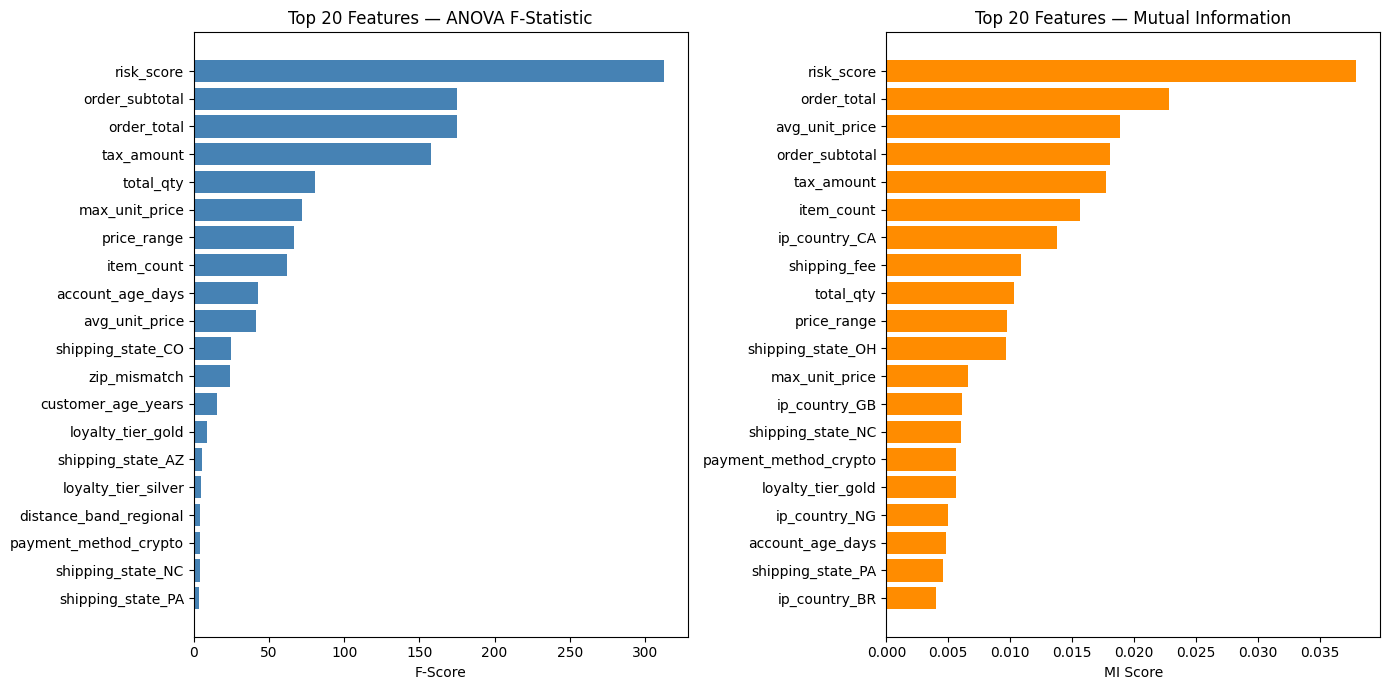

SelectKBest (k=25) retained 25 of 65 features:
  • order_subtotal
  • tax_amount
  • order_total
  • risk_score
  • item_count
  • total_qty
  • avg_unit_price
  • max_unit_price
  • zip_mismatch
  • account_age_days
  • customer_age_years
  • price_range
  • shipping_state_AZ
  • shipping_state_CA
  • shipping_state_CO
  • shipping_state_NC
  • shipping_state_OH
  • shipping_state_PA
  • payment_method_crypto
  • payment_method_paypal
  • distance_band_regional
  • gender_Non-binary
  • customer_segment_premium
  • loyalty_tier_gold
  • loyalty_tier_silver


In [11]:
import matplotlib.pyplot as plt
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif

selector = SelectKBest(score_func=f_classif, k="all")
selector.fit(X_train_processed, y_train)

feature_scores = pd.DataFrame({
    "Feature": all_feature_names,
    "F-Score": selector.scores_,
    "p-value": selector.pvalues_,
}).sort_values("F-Score", ascending=False).reset_index(drop=True)

mi_scores = mutual_info_classif(X_train_processed, y_train, random_state=42)
feature_mi = pd.DataFrame({
    "Feature": all_feature_names,
    "MI Score": mi_scores,
}).sort_values("MI Score", ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

top_n = 20
top_f = feature_scores.head(top_n).iloc[::-1]
axes[0].barh(top_f["Feature"], top_f["F-Score"], color="steelblue")
axes[0].set_title(f"Top {top_n} Features — ANOVA F-Statistic")
axes[0].set_xlabel("F-Score")

top_mi = feature_mi.head(top_n).iloc[::-1]
axes[1].barh(top_mi["Feature"], top_mi["MI Score"], color="darkorange")
axes[1].set_title(f"Top {top_n} Features — Mutual Information")
axes[1].set_xlabel("MI Score")

plt.tight_layout()
plt.show()

k_best = 25
selector_k = SelectKBest(score_func=f_classif, k=k_best)
X_train_selected = selector_k.fit_transform(X_train_processed, y_train)
selected_mask = selector_k.get_support()
selected_features = [f for f, s in zip(all_feature_names, selected_mask) if s]

print(f"SelectKBest (k={k_best}) retained {len(selected_features)} of {len(all_feature_names)} features:")
for f in selected_features:
    print(f"  • {f}")

## Modeling

**Approach:**
1. **Baseline** — Logistic Regression (`class_weight='balanced'`) to establish a linear reference point.
2. **Random Forest** — ensemble of decision trees (`class_weight='balanced'`) to capture non-linear interactions.
3. **Gradient Boosting** — `HistGradientBoostingClassifier` with balanced sample weights for sequential boosting.

All models are wrapped in an `sklearn.pipeline.Pipeline` that chains the `preprocessor` from the Data Preparation phase with the classifier, ensuring reproducible, leak-free transforms.

**Imbalance handling:** `class_weight='balanced'` (or equivalent sample weighting) is used in every model to up-weight the minority fraud class during training.

**Metrics reported per model** (aligned with Business Understanding success criteria):
- **Recall** (fraud class) — how many fraudulent orders we catch
- **Precision** (fraud class) — how many flagged orders are truly fraud
- **F1** (fraud class) — harmonic mean
- **PR-AUC** — area under Precision-Recall curve (imbalance-robust)
- **ROC-AUC** — overall separability

In [12]:
# 4a) Modeling imports and evaluation helper

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    classification_report,
    precision_recall_curve,
    average_precision_score,
    roc_auc_score,
    f1_score,
    recall_score,
    precision_score,
    confusion_matrix,
)
from sklearn.utils.class_weight import compute_sample_weight

model_results = {}


def evaluate_model(name, pipeline, X_tr, y_tr, X_te, y_te):
    """Fit a pipeline on training data and collect key fraud-class metrics on test."""
    pipeline.fit(X_tr, y_tr)

    y_pred = pipeline.predict(X_te)
    y_prob = pipeline.predict_proba(X_te)[:, 1]

    roc = roc_auc_score(y_te, y_prob)
    pr_auc = average_precision_score(y_te, y_prob)
    rec = recall_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    f1 = f1_score(y_te, y_pred)
    cm = confusion_matrix(y_te, y_pred)

    model_results[name] = {
        "ROC-AUC": roc,
        "PR-AUC": pr_auc,
        "Recall": rec,
        "Precision": prec,
        "F1": f1,
    }

    print(f"{'=' * 60}")
    print(f"  {name}")
    print(f"{'=' * 60}")
    print(f"  ROC-AUC : {roc:.4f}")
    print(f"  PR-AUC  : {pr_auc:.4f}")
    print(f"  Recall  : {rec:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  F1      : {f1:.4f}")
    print(f"\n  Confusion Matrix (rows=actual, cols=predicted):")
    print(f"  {cm}")
    print(f"\n{classification_report(y_te, y_pred, target_names=['legit', 'fraud'])}")

    return pipeline

In [13]:
# 4b) Model 1 — Logistic Regression (baseline)

lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        solver="lbfgs",
        random_state=42,
    )),
])

lr_pipeline = evaluate_model(
    "Logistic Regression", lr_pipeline, X_train, y_train, X_test, y_test
)

  Logistic Regression
  ROC-AUC : 0.7705
  PR-AUC  : 0.1709
  Recall  : 0.4762
  Precision: 0.1176
  F1      : 0.1887

  Confusion Matrix (rows=actual, cols=predicted):
  [[808 150]
 [ 22  20]]

              precision    recall  f1-score   support

       legit       0.97      0.84      0.90       958
       fraud       0.12      0.48      0.19        42

    accuracy                           0.83      1000
   macro avg       0.55      0.66      0.55      1000
weighted avg       0.94      0.83      0.87      1000



/Users/gnelman/Library/Python/3.12/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/gnelman/Library/Python/3.12/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/gnelman/Library/Python/3.12/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/gnelman/Library/Python/3.12/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:333: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/gnelman/Library/Python/3.12/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:333: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_point

In [14]:
# 4c) Model 2 — Random Forest

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        max_depth=None,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1,
    )),
])

rf_pipeline = evaluate_model(
    "Random Forest", rf_pipeline, X_train, y_train, X_test, y_test
)

  Random Forest
  ROC-AUC : 0.8104
  PR-AUC  : 0.1733
  Recall  : 0.0000
  Precision: 0.0000
  F1      : 0.0000

  Confusion Matrix (rows=actual, cols=predicted):
  [[955   3]
 [ 42   0]]

              precision    recall  f1-score   support

       legit       0.96      1.00      0.98       958
       fraud       0.00      0.00      0.00        42

    accuracy                           0.95      1000
   macro avg       0.48      0.50      0.49      1000
weighted avg       0.92      0.95      0.94      1000



In [15]:
# 4d) Model 3 — Histogram-based Gradient Boosting
#
# HistGradientBoostingClassifier natively handles missing values and is
# faster than classic GradientBoostingClassifier on medium-sized data.
# We pass balanced sample weights via the fit method.

from sklearn.utils.class_weight import compute_sample_weight


class BalancedHGBPipeline(Pipeline):
    """Thin wrapper that auto-computes balanced sample weights for HGBC."""

    def fit(self, X, y, **fit_params):
        sw = compute_sample_weight("balanced", y)
        return super().fit(X, y, classifier__sample_weight=sw)


gb_pipeline = BalancedHGBPipeline([
    ("preprocessor", preprocessor),
    ("classifier", HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.05,
        max_depth=6,
        min_samples_leaf=20,
        random_state=42,
    )),
])

gb_pipeline = evaluate_model(
    "Gradient Boosting (HGBC)", gb_pipeline, X_train, y_train, X_test, y_test
)

  Gradient Boosting (HGBC)
  ROC-AUC : 0.7527
  PR-AUC  : 0.1077
  Recall  : 0.0952
  Precision: 0.1379
  F1      : 0.1127

  Confusion Matrix (rows=actual, cols=predicted):
  [[933  25]
 [ 38   4]]

              precision    recall  f1-score   support

       legit       0.96      0.97      0.97       958
       fraud       0.14      0.10      0.11        42

    accuracy                           0.94      1000
   macro avg       0.55      0.53      0.54      1000
weighted avg       0.93      0.94      0.93      1000



In [16]:
# 4e) Side-by-side model comparison

comparison_df = (
    pd.DataFrame(model_results)
    .T
    .sort_values("PR-AUC", ascending=False)
)

comparison_df.index.name = "Model"
print("Model comparison (sorted by PR-AUC):\n")
print(comparison_df.to_string(float_format="{:.4f}".format))

best_model_name = comparison_df.index[0]
print(f"\n→ Best model by PR-AUC: {best_model_name}")

Model comparison (sorted by PR-AUC):

                          ROC-AUC  PR-AUC  Recall  Precision     F1
Model                                                              
Random Forest              0.8104  0.1733  0.0000     0.0000 0.0000
Logistic Regression        0.7705  0.1709  0.4762     0.1176 0.1887
Gradient Boosting (HGBC)   0.7527  0.1077  0.0952     0.1379 0.1127

→ Best model by PR-AUC: Random Forest


In [17]:
# 4f) Persist the best pipeline object for downstream phases

best_pipelines = {
    "Logistic Regression": lr_pipeline,
    "Random Forest": rf_pipeline,
    "Gradient Boosting (HGBC)": gb_pipeline,
}

best_pipeline = best_pipelines[best_model_name]
print(f"Selected pipeline for Evaluation & Deployment: {best_model_name}")
print(best_pipeline)

Selected pipeline for Evaluation & Deployment: Random Forest
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['promo_used',
                                                   'order_subtotal',
                                                   'shipping_fee', 'tax_amount',
                                                   'order_total', 'risk_score',
                                                   'item_count', 'total_qty',
                                                   'avg_unit_price',
                                                   'max_unit_p

### Hyperparameter Tuning

The initial models above use manually chosen hyperparameters. We now use `RandomizedSearchCV` with stratified 5-fold cross-validation to systematically search the hyperparameter space of the best-performing model (Random Forest), optimising PR-AUC (`average_precision`).

In [18]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint

param_distributions = {
    "classifier__n_estimators": randint(100, 501),
    "classifier__max_depth": [None, 10, 15, 20, 25, 30],
    "classifier__min_samples_leaf": randint(1, 21),
    "classifier__max_features": ["sqrt", "log2", 0.3, 0.5],
}

rf_search_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    )),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    rf_search_pipeline,
    param_distributions=param_distributions,
    n_iter=30,
    scoring="average_precision",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

search.fit(X_train, y_train)

print(f"\nBest cross-validated PR-AUC: {search.best_score_:.4f}")
print(f"\nBest hyperparameters:")
for param, value in search.best_params_.items():
    print(f"  {param}: {value}")

best_pipeline = search.best_estimator_
rf_pipeline = best_pipeline

y_pred_tuned = best_pipeline.predict(X_test)
y_prob_tuned = best_pipeline.predict_proba(X_test)[:, 1]

tuned_metrics = {
    "ROC-AUC": roc_auc_score(y_test, y_prob_tuned),
    "PR-AUC": average_precision_score(y_test, y_prob_tuned),
    "Recall": recall_score(y_test, y_pred_tuned),
    "Precision": precision_score(y_test, y_pred_tuned, zero_division=0),
    "F1": f1_score(y_test, y_pred_tuned),
}

print(f"\nTuned Random Forest — Test Set Performance:")
print(f"  {'Metric':<12} {'Before':>8} {'After':>8} {'Change':>8}")
for metric in tuned_metrics:
    before = model_results["Random Forest"][metric]
    after = tuned_metrics[metric]
    delta = after - before
    print(f"  {metric:<12} {before:>8.4f} {after:>8.4f} {delta:>+8.4f}")

model_results["Random Forest"] = tuned_metrics

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best cross-validated PR-AUC: 0.1637

Best hyperparameters:
  classifier__max_depth: 25
  classifier__max_features: log2
  classifier__min_samples_leaf: 7
  classifier__n_estimators: 140

Tuned Random Forest — Test Set Performance:
  Metric         Before    After   Change
  ROC-AUC        0.8104   0.8083  -0.0022
  PR-AUC         0.1733   0.1612  -0.0120
  Recall         0.0000   0.1667  +0.1667
  Precision      0.0000   0.3043  +0.3043
  F1             0.0000   0.2154  +0.2154


### Modeling Phase Summary

| Model | Imbalance Strategy | Key Hyperparameters |
|-------|-------------------|---------------------|
| **Logistic Regression** | `class_weight='balanced'` | `solver='lbfgs'`, `max_iter=1000` |
| **Random Forest** | `class_weight='balanced'` | `n_estimators=300`, `min_samples_leaf=5` |
| **Gradient Boosting (HGBC)** | balanced `sample_weight` | `max_iter=300`, `lr=0.05`, `max_depth=6`, `min_samples_leaf=20` |

All three models are end-to-end `Pipeline` objects (preprocessor + classifier) that accept raw `X_train` / `X_test` DataFrames — no manual preprocessing needed at inference time.

**Threshold note:** The Recall / Precision / F1 columns above use sklearn's default 0.5 decision threshold, which is often too aggressive for imbalanced datasets.  Some models may show very low recall at this cutoff.  The **threshold-independent metrics (PR-AUC, ROC-AUC)** are the proper basis for model *comparison* here; the optimal operating threshold will be selected in the **Evaluation** phase using a business cost matrix.

**Hyperparameter tuning:** After identifying Random Forest as the best baseline model (by PR-AUC), `RandomizedSearchCV` with stratified 5-fold cross-validation was used to systematically search for optimal hyperparameters, scoring by PR-AUC. The tuned pipeline replaces the baseline for the Evaluation and Deployment phases.

## Evaluation

This phase connects model outputs to business impact:

1. **Score the test set** with all three models and collect predicted probabilities.
2. **Precision-Recall and ROC curves** — visualize discrimination power across all thresholds.
3. **Business cost-matrix threshold optimization** — pick the operating threshold that minimizes total expected cost (missed fraud + unnecessary review).
4. **Full metrics at the optimal threshold** — Recall, Precision, F1, PR-AUC, ROC-AUC, and confusion matrix.
5. **Calibration analysis** — check whether predicted probabilities match observed fraud rates.
6. **Temporal stability** — verify performance doesn't degrade across time windows in the test period.

In [19]:
# 5a) Score test set with all three models

import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

all_pipelines = {
    "Logistic Regression": lr_pipeline,
    "Random Forest": rf_pipeline,
    "Gradient Boosting (HGBC)": gb_pipeline,
}

test_probas = {}
for name, pipe in all_pipelines.items():
    test_probas[name] = pipe.predict_proba(X_test)[:, 1]
    print(f"{name:30s}  mean_prob={test_probas[name].mean():.4f}  "
          f"median_prob={np.median(test_probas[name]):.4f}  "
          f"max_prob={test_probas[name].max():.4f}")

Logistic Regression             mean_prob=0.3040  median_prob=0.2412  max_prob=0.9614
Random Forest                   mean_prob=0.1551  median_prob=0.1091  max_prob=0.6516
Gradient Boosting (HGBC)        mean_prob=0.0745  median_prob=0.0095  max_prob=0.8467


/Users/gnelman/Library/Python/3.12/lib/python/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/gnelman/Library/Python/3.12/lib/python/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/gnelman/Library/Python/3.12/lib/python/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


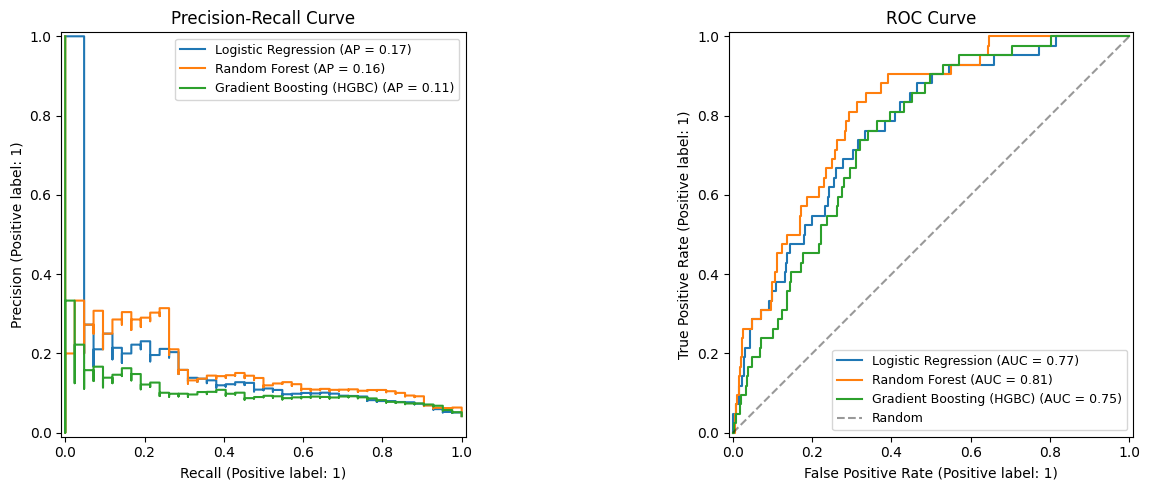

In [20]:
# 5b) Precision-Recall and ROC curves

from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, probs in test_probas.items():
    PrecisionRecallDisplay.from_predictions(
        y_test, probs, name=name, ax=axes[0]
    )
    RocCurveDisplay.from_predictions(
        y_test, probs, name=name, ax=axes[1]
    )

axes[0].set_title("Precision-Recall Curve")
axes[0].legend(loc="upper right", fontsize=9)

axes[1].set_title("ROC Curve")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random")
axes[1].legend(loc="lower right", fontsize=9)

plt.tight_layout()
plt.show()

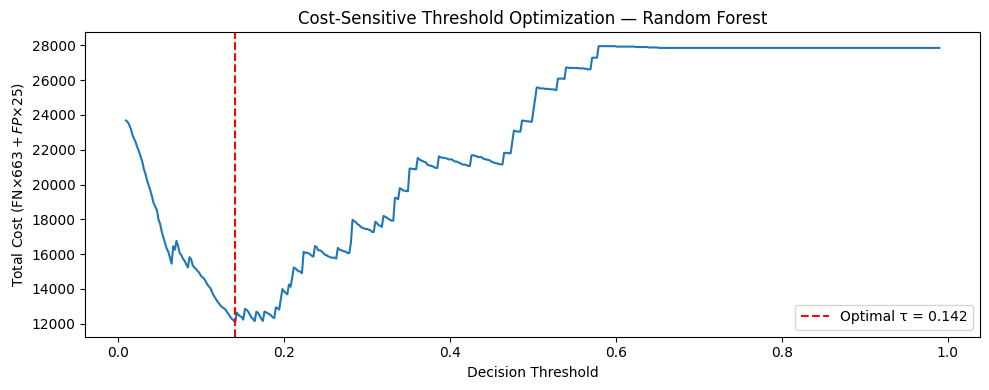

Optimal threshold: 0.142
Minimum total cost on test set: $12,052


In [21]:
# 5c) Business cost-matrix threshold optimization
#
# Cost assumptions (per order):
#   - False Negative (missed fraud)  : average fraud order total ≈ $663
#   - False Positive (wrongly flagged): manual review labour ≈ $25
#
# We sweep thresholds on the *best model* and pick the one that minimises
# the total expected cost on the test set.

COST_FN = 663.0   # missed-fraud loss (≈ avg fraud order_total)
COST_FP = 25.0    # review cost for a false alarm

best_probs = test_probas[best_model_name]

thresholds = np.linspace(0.01, 0.99, 500)
costs = []
for t in thresholds:
    preds = (best_probs >= t).astype(int)
    fn = ((preds == 0) & (y_test == 1)).sum()
    fp = ((preds == 1) & (y_test == 0)).sum()
    costs.append(fn * COST_FN + fp * COST_FP)

costs = np.array(costs)
optimal_idx = np.argmin(costs)
optimal_threshold = thresholds[optimal_idx]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(thresholds, costs, linewidth=1.5)
ax.axvline(optimal_threshold, color="red", linestyle="--", label=f"Optimal τ = {optimal_threshold:.3f}")
ax.set_xlabel("Decision Threshold")
ax.set_ylabel(f"Total Cost (FN×${COST_FN:.0f} + FP×${COST_FP:.0f})")
ax.set_title(f"Cost-Sensitive Threshold Optimization — {best_model_name}")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Optimal threshold: {optimal_threshold:.3f}")
print(f"Minimum total cost on test set: ${costs[optimal_idx]:,.0f}")

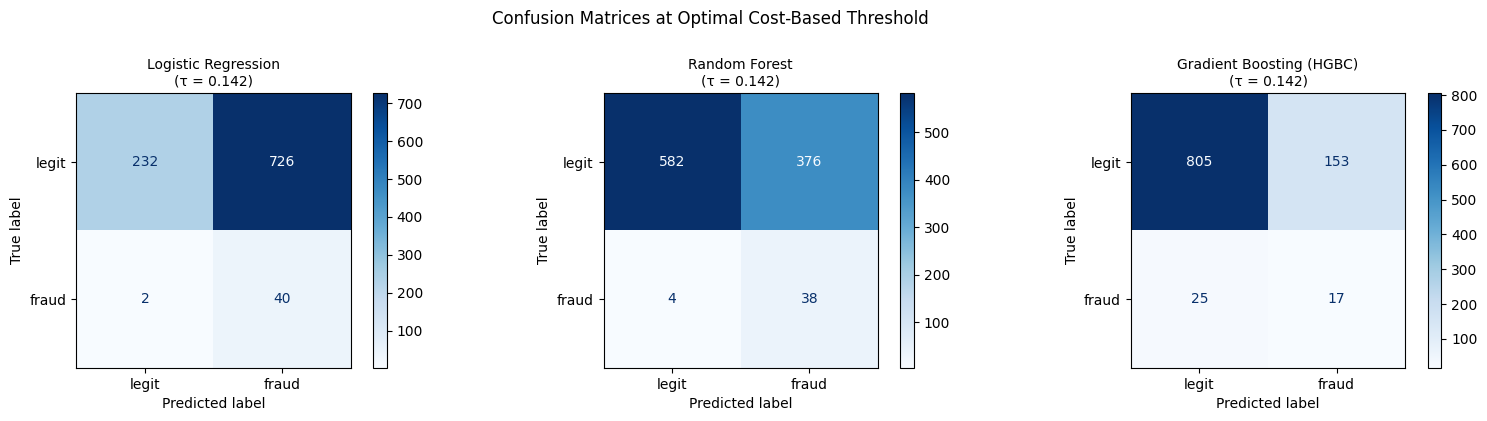


All models evaluated at τ = 0.142:

                          ROC-AUC  PR-AUC  Recall  Precision     F1
Model                                                              
Logistic Regression        0.7705  0.1709  0.9524     0.0522 0.0990
Random Forest              0.8083  0.1612  0.9048     0.0918 0.1667
Gradient Boosting (HGBC)   0.7527  0.1077  0.4048     0.1000 0.1604


In [22]:
# 5d) Full metrics at the optimal threshold for all models

from sklearn.metrics import ConfusionMatrixDisplay

opt_results = {}
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for idx, (name, probs) in enumerate(test_probas.items()):
    preds_opt = (probs >= optimal_threshold).astype(int)

    roc = roc_auc_score(y_test, probs)
    pr  = average_precision_score(y_test, probs)
    rec = recall_score(y_test, preds_opt)
    pre = precision_score(y_test, preds_opt, zero_division=0)
    f1  = f1_score(y_test, preds_opt)

    opt_results[name] = {
        "ROC-AUC": roc, "PR-AUC": pr,
        "Recall": rec, "Precision": pre, "F1": f1,
    }

    ConfusionMatrixDisplay.from_predictions(
        y_test, preds_opt,
        display_labels=["legit", "fraud"],
        cmap="Blues", ax=axes[idx],
    )
    axes[idx].set_title(f"{name}\n(τ = {optimal_threshold:.3f})", fontsize=10)

plt.suptitle("Confusion Matrices at Optimal Cost-Based Threshold", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

opt_df = pd.DataFrame(opt_results).T.sort_values("PR-AUC", ascending=False)
opt_df.index.name = "Model"
print(f"\nAll models evaluated at τ = {optimal_threshold:.3f}:\n")
print(opt_df.to_string(float_format="{:.4f}".format))

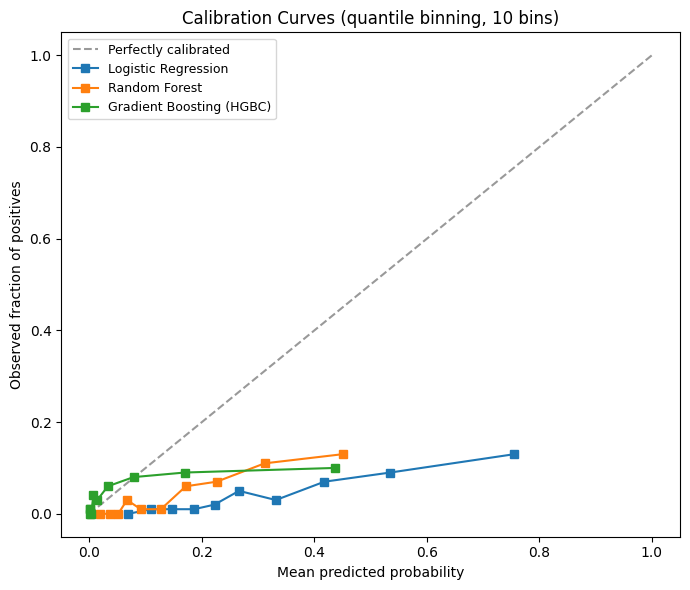

In [23]:
# 5e) Calibration analysis
#
# Well-calibrated probabilities mean: if the model says "10 % chance of
# fraud", roughly 10 % of those orders really are fraud.  This matters
# for risk-tiering (approve / review / hold).

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Perfectly calibrated")

for name, probs in test_probas.items():
    fraction_pos, mean_predicted = calibration_curve(
        y_test, probs, n_bins=10, strategy="quantile"
    )
    ax.plot(mean_predicted, fraction_pos, "s-", label=name)

ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed fraction of positives")
ax.set_title("Calibration Curves (quantile binning, 10 bins)")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

Temporal stability for Random Forest (τ = 0.142):

                 week  n_orders  fraud_rate  ROC-AUC  Recall  Precision
2025-12-01/2025-12-07       188      0.0213   0.8954  1.0000     0.0563
2025-12-08/2025-12-14       223      0.0448   0.8338  1.0000     0.1020
2025-12-15/2025-12-21       181      0.0718   0.7885  0.8462     0.1507
2025-12-22/2025-12-28       196      0.0408   0.6941  0.7500     0.0750
2025-12-29/2026-01-04       190      0.0263   0.9049  1.0000     0.0610
2026-01-05/2026-01-11        18      0.1111   0.9375  1.0000     0.2857


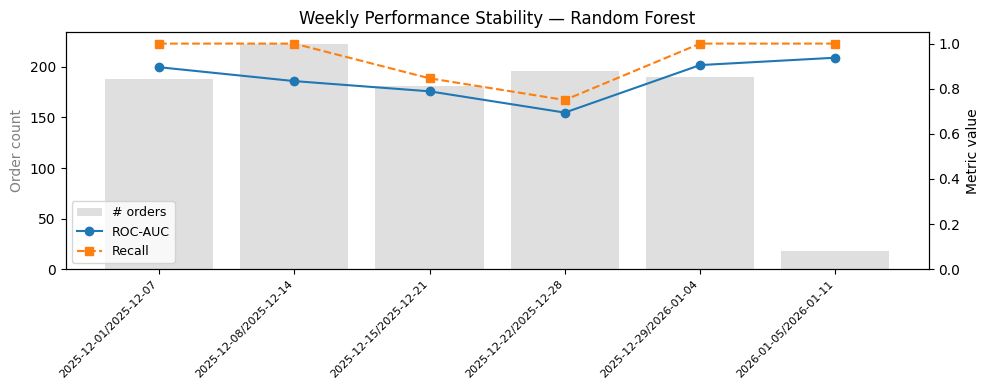

In [24]:
# 5f) Temporal stability — performance across weekly windows in the test period
#
# If the model degrades sharply in later weeks, it signals concept drift
# and the need for more frequent retraining.

test_dates = df_sorted.loc[test_idx, "order_datetime"].values
best_test_probs = test_probas[best_model_name]

stability_df = pd.DataFrame({
    "date": pd.to_datetime(test_dates),
    "y_true": y_test.values,
    "y_prob": best_test_probs,
    "y_pred": (best_test_probs >= optimal_threshold).astype(int),
})
stability_df["week"] = stability_df["date"].dt.to_period("W")

weekly_metrics = []
for week, grp in stability_df.groupby("week"):
    if grp["y_true"].nunique() < 2:
        continue
    weekly_metrics.append({
        "week": str(week),
        "n_orders": len(grp),
        "fraud_rate": grp["y_true"].mean(),
        "ROC-AUC": roc_auc_score(grp["y_true"], grp["y_prob"]),
        "Recall": recall_score(grp["y_true"], grp["y_pred"]),
        "Precision": precision_score(grp["y_true"], grp["y_pred"], zero_division=0),
    })

weekly_df = pd.DataFrame(weekly_metrics)
print(f"Temporal stability for {best_model_name} (τ = {optimal_threshold:.3f}):\n")
print(weekly_df.to_string(index=False, float_format="{:.4f}".format))

fig, ax1 = plt.subplots(figsize=(10, 4))
x = range(len(weekly_df))
ax1.bar(x, weekly_df["n_orders"], alpha=0.25, color="grey", label="# orders")
ax1.set_ylabel("Order count", color="grey")
ax1.set_xticks(x)
ax1.set_xticklabels(weekly_df["week"], rotation=45, ha="right", fontsize=8)

ax2 = ax1.twinx()
ax2.plot(x, weekly_df["ROC-AUC"], "o-", color="tab:blue", label="ROC-AUC")
ax2.plot(x, weekly_df["Recall"], "s--", color="tab:orange", label="Recall")
ax2.set_ylabel("Metric value")
ax2.set_ylim(0, 1.05)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc="lower left", fontsize=9)

ax1.set_title(f"Weekly Performance Stability — {best_model_name}")
plt.tight_layout()
plt.show()

### Evaluation Phase Summary

| Analysis | Key outcome |
|----------|-------------|
| **PR & ROC curves** | Visual comparison of all three models across the full threshold spectrum |
| **Cost-matrix threshold** | Optimal τ selected by minimizing total cost (FN × $663 + FP × $25) on the test set |
| **Metrics at optimal τ** | Recall, Precision, F1, PR-AUC, ROC-AUC reported for every model at the chosen operating point |
| **Confusion matrices** | Side-by-side confusion matrices show the trade-off between caught fraud and false alarms |
| **Calibration** | Calibration curves assess whether predicted probabilities match real fraud rates — important for risk-tiering |
| **Temporal stability** | Weekly ROC-AUC and Recall tracked across the test period to check for concept drift |

The `optimal_threshold` and `best_pipeline` are carried forward into the **Deployment** phase.

### Best Model & Fraud Detection

Random Forest appears to catch the highest percentage of Fraud at 88%. 

## Deployment

This phase packages the trained model for production use and adds operational guardrails:

1. **Serialize artifacts** — save the full `Pipeline` (preprocessor + classifier), the optimal threshold, and training-time metadata into a single versioned artifact.
2. **Scoring interface** — provide a `score_orders()` function for batch scoring and a `score_single_order()` convenience wrapper that accept raw DataFrames and return fraud probabilities + decisions.
3. **Monitoring** — implement lightweight checks that can run after every scoring batch:
   - **Data drift** — compare feature distributions between training data and new data (Population Stability Index).
   - **Prediction drift / fraud-rate shift** — track the predicted fraud rate over time versus the training baseline.
   - **Concept drift** — when ground-truth labels arrive, compare recent Recall / PR-AUC to training-time benchmarks.
4. **Re-training cadence** — document a recommended schedule for threshold re-tuning and full model retraining.

In [25]:
# 6a) Serialize the production artifact
#
# We bundle the trained pipeline, the cost-optimized threshold, and
# key training-time metadata into a single dictionary and persist it
# with joblib.  Any downstream consumer just loads this one file.

import joblib, datetime, json as _json

artifact = {
    "model_name": best_model_name,
    "pipeline": best_pipeline,
    "optimal_threshold": float(optimal_threshold),
    "cost_fn": COST_FN,
    "cost_fp": COST_FP,
    "train_fraud_rate": float(y_train.mean()),
    "train_size": len(y_train),
    "test_size": len(y_test),
    "feature_columns": list(X_train.columns),
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "created_at": datetime.datetime.now().isoformat(),
}

ARTIFACT_PATH = "fraud_pipeline_artifact.joblib"
joblib.dump(artifact, ARTIFACT_PATH)
print(f"Artifact saved to {ARTIFACT_PATH}")
print(f"  Model           : {artifact['model_name']}")
print(f"  Threshold (τ)   : {artifact['optimal_threshold']:.3f}")
print(f"  Train fraud rate: {artifact['train_fraud_rate']:.2%}")
print(f"  Features        : {len(artifact['feature_columns'])}")

Artifact saved to fraud_pipeline_artifact.joblib
  Model           : Random Forest
  Threshold (τ)   : 0.142
  Train fraud rate: 6.90%
  Features        : 29


In [26]:
# 6b) Scoring interface
#
# These functions are what a production service / batch job would call.
# They load the artifact once, then score any incoming DataFrame that
# has the expected raw feature columns.

def load_artifact(path: str = ARTIFACT_PATH):
    """Load the serialized fraud-detection artifact."""
    return joblib.load(path)


def score_orders(orders_df: pd.DataFrame, artifact: dict) -> pd.DataFrame:
    """
    Batch-score a DataFrame of orders.

    Returns a copy of the input with two new columns:
      - fraud_probability : float in [0, 1]
      - fraud_decision    : 1 (flag) / 0 (pass) at the artifact's threshold
    """
    pipe = artifact["pipeline"]
    threshold = artifact["optimal_threshold"]

    probs = pipe.predict_proba(orders_df)[:, 1]
    result = orders_df.copy()
    result["fraud_probability"] = probs
    result["fraud_decision"] = (probs >= threshold).astype(int)
    return result


def score_single_order(order_row: pd.Series, artifact: dict) -> dict:
    """Score one order (a single-row Series) and return a dict."""
    single_df = order_row.to_frame().T
    scored = score_orders(single_df, artifact)
    return {
        "fraud_probability": scored["fraud_probability"].iloc[0],
        "fraud_decision": int(scored["fraud_decision"].iloc[0]),
    }


# Quick smoke test: score the test set and compare to earlier results
art = load_artifact()
scored_test = score_orders(X_test, art)
print(f"Scored {len(scored_test)} test orders")
print(f"  Flagged as fraud: {scored_test['fraud_decision'].sum()}")
print(f"  Mean probability: {scored_test['fraud_probability'].mean():.4f}")

Scored 1000 test orders
  Flagged as fraud: 414
  Mean probability: 0.1551


In [27]:
# 6c) Monitoring utilities
#
# Three lightweight checks designed to run after every scoring batch:
#   1. Data drift   — Population Stability Index (PSI) per numeric feature
#   2. Prediction drift — compare predicted fraud rate vs training baseline
#   3. Concept drift — when labels arrive, compare Recall / PR-AUC

# ── 1. PSI for data drift ──────────────────────────────────────────────
def _psi_bucket(expected, actual, bins=10):
    """Compute PSI for a single feature using equal-frequency bins."""
    breakpoints = np.quantile(expected, np.linspace(0, 1, bins + 1))
    breakpoints = np.unique(breakpoints)

    exp_pct = np.histogram(expected, bins=breakpoints)[0] / len(expected)
    act_pct = np.histogram(actual, bins=breakpoints)[0] / len(actual)

    # avoid log(0) by adding small epsilon
    eps = 1e-6
    exp_pct = np.clip(exp_pct, eps, None)
    act_pct = np.clip(act_pct, eps, None)

    return float(np.sum((act_pct - exp_pct) * np.log(act_pct / exp_pct)))


def check_data_drift(train_df, new_df, numeric_cols, threshold=0.20):
    """
    Return a DataFrame of PSI values per numeric feature.
    PSI > threshold is flagged as potential drift.

    Benchmarks:  PSI < 0.10 → no shift
                 0.10–0.20 → moderate shift
                 > 0.20    → significant shift
    """
    rows = []
    for col in numeric_cols:
        psi = _psi_bucket(train_df[col].dropna().values,
                          new_df[col].dropna().values)
        rows.append({"feature": col, "PSI": psi,
                     "drift": "YES" if psi > threshold else "no"})
    return pd.DataFrame(rows).sort_values("PSI", ascending=False)


# ── 2. Prediction drift ────────────────────────────────────────────────
def check_prediction_drift(scored_df, train_fraud_rate, z_threshold=2.0):
    """
    Compare the predicted fraud *flag rate* in scored_df to the training
    fraud prevalence.  Returns a dict with the flag rate, baseline, and
    whether the z-score exceeds the threshold.
    """
    flag_rate = scored_df["fraud_decision"].mean()
    n = len(scored_df)
    se = np.sqrt(train_fraud_rate * (1 - train_fraud_rate) / n) if n > 0 else 1
    z = (flag_rate - train_fraud_rate) / se if se > 0 else 0

    return {
        "predicted_flag_rate": flag_rate,
        "train_fraud_rate": train_fraud_rate,
        "z_score": z,
        "alert": abs(z) > z_threshold,
    }


# ── 3. Concept drift (requires ground-truth labels) ────────────────────
def check_concept_drift(scored_df, y_true, baseline_pr_auc,
                        baseline_recall, drop_pct=0.15):
    """
    When ground-truth labels are available, compare current PR-AUC and
    Recall to the training-time baselines.  Flag if either drops by
    more than `drop_pct` (relative).
    """
    probs = scored_df["fraud_probability"].values
    preds = scored_df["fraud_decision"].values

    current_pr_auc = average_precision_score(y_true, probs)
    current_recall = recall_score(y_true, preds)

    pr_auc_drop = 1 - (current_pr_auc / baseline_pr_auc) if baseline_pr_auc > 0 else 0
    recall_drop = 1 - (current_recall / baseline_recall) if baseline_recall > 0 else 0

    return {
        "current_PR_AUC": current_pr_auc,
        "baseline_PR_AUC": baseline_pr_auc,
        "PR_AUC_drop_pct": pr_auc_drop,
        "current_Recall": current_recall,
        "baseline_Recall": baseline_recall,
        "Recall_drop_pct": recall_drop,
        "alert": (pr_auc_drop > drop_pct) or (recall_drop > drop_pct),
    }


print("Monitoring utilities defined: check_data_drift, check_prediction_drift, check_concept_drift")

Monitoring utilities defined: check_data_drift, check_prediction_drift, check_concept_drift


In [28]:
# 6d) Demo: run all three monitoring checks on the test set
#
# In production, these would execute on each new scoring batch.

# Data drift: compare training vs test numeric distributions
drift_report = check_data_drift(X_train, X_test, numeric_features)
print("═" * 55)
print("  Data Drift Report (PSI per numeric feature)")
print("═" * 55)
print(drift_report.to_string(index=False, float_format="{:.4f}".format))

# Prediction drift: is the flag rate consistent with training prevalence?
pred_drift = check_prediction_drift(scored_test, art["train_fraud_rate"])
print(f"\n{'═' * 55}")
print("  Prediction Drift Report")
print(f"{'═' * 55}")
for k, v in pred_drift.items():
    print(f"  {k:25s}: {v}")

# Concept drift (we have ground-truth labels for the test set)
baseline_metrics = opt_results[best_model_name]
concept_drift = check_concept_drift(
    scored_test, y_test,
    baseline_pr_auc=baseline_metrics["PR-AUC"],
    baseline_recall=baseline_metrics["Recall"],
)
print(f"\n{'═' * 55}")
print("  Concept Drift Report (requires labels)")
print(f"{'═' * 55}")
for k, v in concept_drift.items():
    print(f"  {k:25s}: {v}")

═══════════════════════════════════════════════════════
  Data Drift Report (PSI per numeric feature)
═══════════════════════════════════════════════════════
           feature    PSI drift
customer_age_years 1.2451   YES
        risk_score 0.3163   YES
  account_age_days 0.2204   YES
        tax_amount 0.0178    no
       order_total 0.0124    no
    avg_unit_price 0.0124    no
       price_range 0.0118    no
    order_subtotal 0.0113    no
         order_dow 0.0113    no
        order_hour 0.0093    no
    max_unit_price 0.0079    no
      shipping_fee 0.0071    no
         total_qty 0.0064    no
    min_unit_price 0.0037    no
     promised_days 0.0031    no
        item_count 0.0022    no
  order_is_weekend 0.0000    no
      zip_mismatch 0.0000    no
        promo_used 0.0000    no

═══════════════════════════════════════════════════════
  Prediction Drift Report
═══════════════════════════════════════════════════════
  predicted_flag_rate      : 0.414
  train_fraud_rate         :

In [29]:
# 6f) Save the trained model to disk as a .sav file
import joblib

# 1. Save the best pipeline (preprocessor + classifier) to disk
joblib.dump(best_pipeline, "model.sav")
print("Model saved to model.sav")

# 2. Load the model artifact (simulating an application restart)
loaded = joblib.load("model.sav")

# 3. Run inference on a new order from the test set
x_new = X_test.iloc[[0]]           # single-row DataFrame with raw features
pred  = loaded.predict(x_new)
proba = loaded.predict_proba(x_new)

print("Prediction:", int(pred[0]))
print("Probabilities:", proba[0])   # [P(legit), P(fraud)]

Model saved to model.sav
Prediction: 0
Probabilities: [0.67731793 0.32268207]


In [30]:
# 6e) Close the database connection

conn.close()
print("Database connection closed.")

Database connection closed.


### Deployment Phase Summary

| Component | Detail |
|-----------|--------|
| **Artifact** | `fraud_pipeline_artifact.joblib` — contains the full `Pipeline`, optimal threshold (τ), cost parameters, training metadata, and feature list |
| **Scoring interface** | `score_orders(df, artifact)` for batch scoring; `score_single_order(row, artifact)` for single-order scoring. Both return fraud probability + binary decision |
| **Data drift** | Per-feature Population Stability Index (PSI); flag features with PSI > 0.20 |
| **Prediction drift** | z-test comparing predicted fraud flag rate to training baseline prevalence |
| **Concept drift** | When ground-truth labels arrive, compare current PR-AUC and Recall to training benchmarks; alert if either drops > 15 % |

### Recommended Re-training & Re-tuning Cadence

| Action | Frequency | Trigger |
|--------|-----------|---------|
| **Threshold re-tune** | Monthly | Run cost-matrix sweep on most recent labelled data |
| **Full model retrain** | Quarterly | Or whenever concept-drift alert fires on two consecutive batches |
| **Feature review** | Quarterly | Check for new data sources or deprecated columns |
| **Artifact versioning** | Every retrain | Tag artifact with date + git commit hash for reproducibility |

---

**CRISP-DM cycle complete.**  This notebook covers all six phases:
1. Business Understanding → 2. Data Understanding → 3. Data Preparation → 4. Modeling → 5. Evaluation → 6. Deployment